PyTorch : 2.12.1
Device : mps


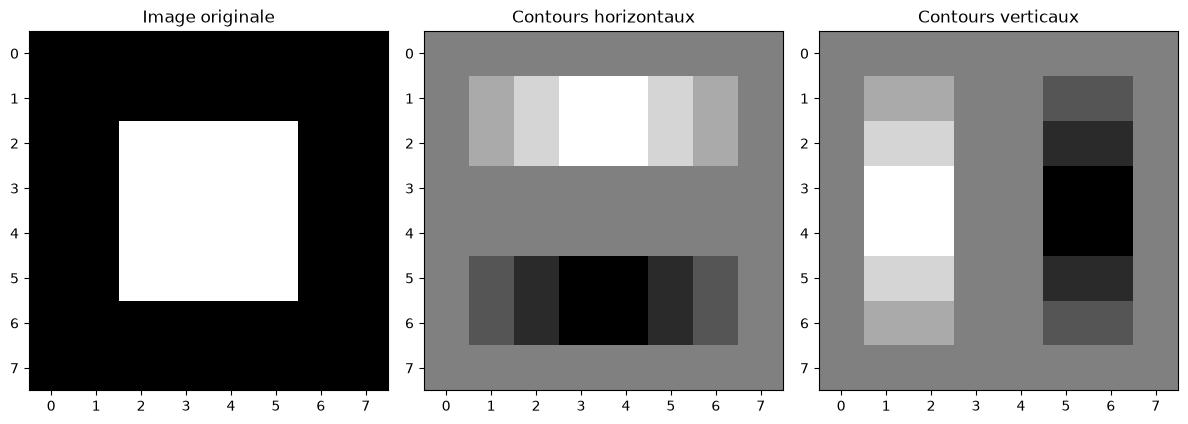

Un CNN apprend automatiquement ces filtres pendant l'entraînement !


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch : {torch.__version__}")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device : {device}")

# COMPRENDRE UNE CONVOLUTION
# Un filtre (kernel) détecte des patterns locaux dans une image

# Filtre de détection de contours horizontaux
filtre_horizontal = torch.tensor([
    [-1., -1., -1.],
    [ 0.,  0.,  0.],
    [ 1.,  1.,  1.]
]).unsqueeze(0).unsqueeze(0)   # shape (1, 1, 3, 3)

# Filtre de détection de contours verticaux
filtre_vertical = torch.tensor([
    [-1., 0., 1.],
    [-1., 0., 1.],
    [-1., 0., 1.]
]).unsqueeze(0).unsqueeze(0)

# Image synthétique (carré blanc sur fond noir)
image = torch.zeros(1, 1, 8, 8)
image[0, 0, 2:6, 2:6] = 1.0   # carré blanc au centre

conv_h = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
conv_v = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
conv_h.weight.data = filtre_horizontal
conv_v.weight.data = filtre_vertical

with torch.no_grad():
    result_h = conv_h(image)
    result_v = conv_v(image)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image[0, 0].numpy(), cmap="gray")
axes[0].set_title("Image originale")
axes[1].imshow(result_h[0, 0].detach().numpy(), cmap="gray")
axes[1].set_title("Contours horizontaux")
axes[2].imshow(result_v[0, 0].detach().numpy(), cmap="gray")
axes[2].set_title("Contours verticaux")
plt.tight_layout()
plt.show()

print("Un CNN apprend automatiquement ces filtres pendant l'entraînement !")

Téléchargement de MNIST...


100.0%
100.0%
100.0%
100.0%


Train : 60000 images
Test  : 10000 images


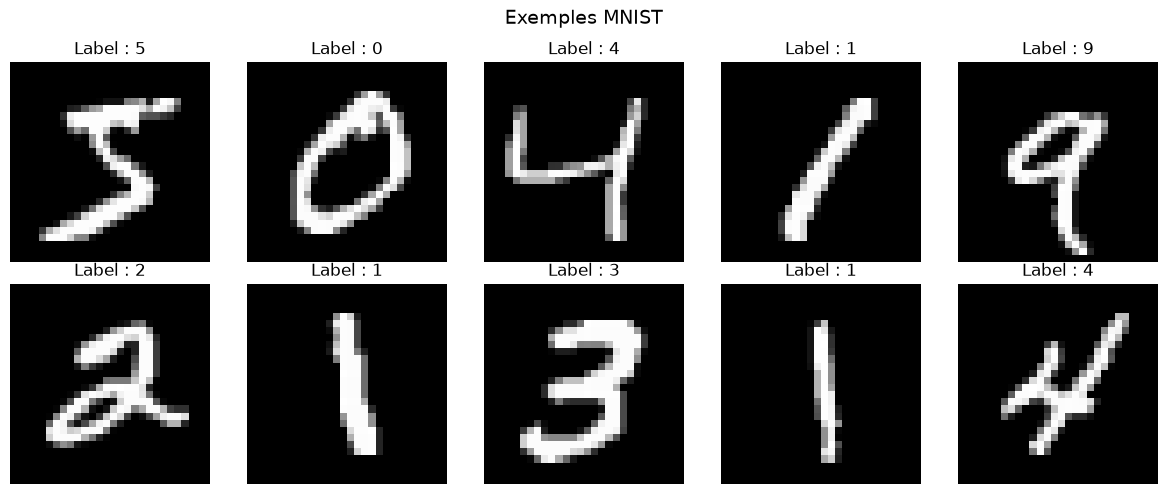

In [2]:
# MNIST — 70000 images de chiffres (0-9), 28x28 pixels, niveaux de gris

# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Télécharger MNIST
print("Téléchargement de MNIST...")
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False
)

print(f"Train : {len(train_dataset)} images")
print(f"Test  : {len(test_dataset)} images")

# Visualiser quelques exemples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label : {label}")
    ax.axis("off")
plt.suptitle("Exemples MNIST", fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
# ARCHITECTURE CNN POUR MNIST
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Feature extractor
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (1,28,28) → (32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # (32,28,28) → (32,14,14)
            
            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (32,14,14) → (64,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # (64,14,14) → (64,7,7)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)   # 10 classes (0-9)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instancier
model = CNN().to(device)
print(model)
print(f"\nParamètres : {sum(p.numel() for p in model.parameters()):,}")

# Loss et optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Entraînement
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (output.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss/len(loader), 100*correct/total

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            correct += (output.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss/len(loader), 100*correct/total

# Entraîner 5 epochs
print("\nEntraînement...")
for epoch in range(5):
    train_loss, train_acc = train_epoch(model, train_loader)
    test_loss, test_acc = eval_epoch(model, test_loader)
    print(f"Epoch [{epoch+1}/5] "
          f"Train: {train_acc:.2f}% | "
          f"Test: {test_acc:.2f}%")

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Paramètres : 421,642

Entraînement...
Epoch [1/5] Train: 94.92% | Test: 98.43%
Epoch [2/5] Train: 98.19% | Test: 98.87%
Epoch [3/5] Train: 98.74% | Test: 99.09%
Epoch [4/5] Train: 98.95% | Test: 99.06%
Epoch [5/5] Train: 99.19% | Test: 99.07%


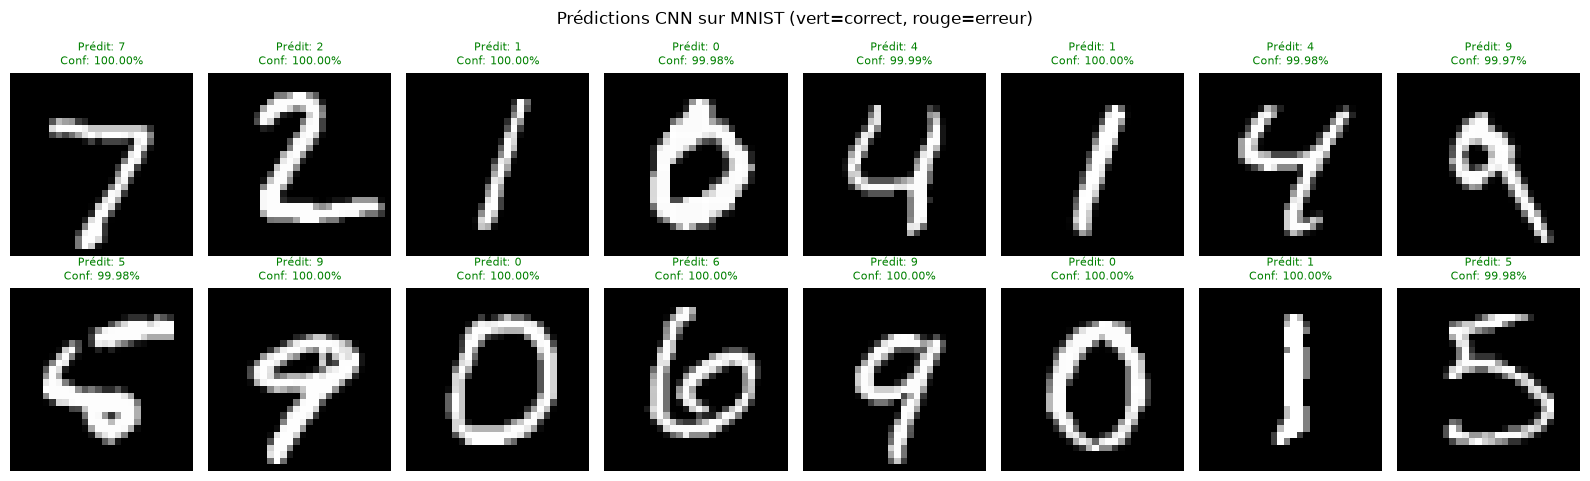

In [4]:
# VISUALISER LES PRÉDICTIONS
model.eval()

# Prendre un batch de test
images, labels = next(iter(test_loader))
images_device = images[:16].to(device)

with torch.no_grad():
    outputs = model(images_device)
    predictions = outputs.argmax(1).cpu()
    probabilities = torch.softmax(outputs, dim=1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    pred = predictions[i].item()
    true = labels[i].item()
    conf = probabilities[i][pred].item()
    
    color = "green" if pred == true else "red"
    ax.set_title(f"Prédit: {pred}\nConf: {conf:.2%}", 
                 color=color, fontsize=8)
    ax.axis("off")

plt.suptitle("Prédictions CNN sur MNIST (vert=correct, rouge=erreur)", 
             fontsize=12)
plt.tight_layout()
plt.show()

Device : mps

=== TRANSFER LEARNING avec ResNet18 ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/zooherhoussen/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [01:07<00:00, 694kB/s] 


Architecture ResNet18 :
  Couches : 10
  Paramètres totaux : 11,689,512

Stratégie : Feature Extraction
Paramètres totaux    : 11,177,538
Paramètres entraînés : 1,026
Pourcentage entraîné : 0.01%

Stratégie : Fine-tuning (layer4 + fc)
Paramètres entraînés : 8,394,754
Pourcentage entraîné : 75.10%


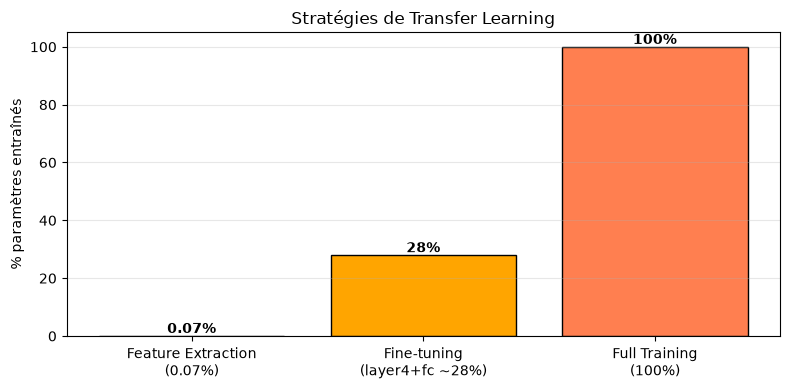


=== QUAND UTILISER QUOI ? ===

Feature Extraction → Peu de données, tâche similaire à ImageNet
Fine-tuning        → Données moyennes, tâche légèrement différente  
Full Training      → Beaucoup de données, tâche très différente



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device : {device}")

# TRANSFER LEARNING
# Utiliser un modèle pré-entraîné sur ImageNet (1.2M images, 1000 classes)
# et l'adapter à notre tâche

print("\n=== TRANSFER LEARNING avec ResNet18 ===")

# Charger ResNet18 pré-entraîné
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

print("Architecture ResNet18 :")
print(f"  Couches : {len(list(resnet.children()))}")
print(f"  Paramètres totaux : {sum(p.numel() for p in resnet.parameters()):,}")

# STRATÉGIE 1 : Feature Extraction
# Geler toutes les couches sauf la dernière
for param in resnet.parameters():
    param.requires_grad = False

# Remplacer la couche finale
n_features = resnet.fc.in_features
resnet.fc = nn.Linear(n_features, 2)  # 2 classes au lieu de 1000

params_trainables = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
params_totaux = sum(p.numel() for p in resnet.parameters())

print(f"\nStratégie : Feature Extraction")
print(f"Paramètres totaux    : {params_totaux:,}")
print(f"Paramètres entraînés : {params_trainables:,}")
print(f"Pourcentage entraîné : {100*params_trainables/params_totaux:.2f}%")

# STRATÉGIE 2 : Fine-tuning
resnet2 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Geler seulement les premières couches
for name, param in resnet2.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False

# Remplacer la couche finale
resnet2.fc = nn.Linear(resnet2.fc.in_features, 2)

params_trainables2 = sum(p.numel() for p in resnet2.parameters() if p.requires_grad)
print(f"\nStratégie : Fine-tuning (layer4 + fc)")
print(f"Paramètres entraînés : {params_trainables2:,}")
print(f"Pourcentage entraîné : {100*params_trainables2/params_totaux:.2f}%")

# Visualisation des stratégies
strategies = ["Feature Extraction\n(0.07%)", "Fine-tuning\n(layer4+fc ~28%)", "Full Training\n(100%)"]
pcts = [0.07, 28, 100]
colors = ["steelblue", "orange", "coral"]

plt.figure(figsize=(8, 4))
bars = plt.bar(strategies, pcts, color=colors, edgecolor="black")
plt.ylabel("% paramètres entraînés")
plt.title("Stratégies de Transfer Learning")
plt.grid(True, alpha=0.3, axis="y")
for bar, pct in zip(bars, pcts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{pct}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== QUAND UTILISER QUOI ? ===")
print("""
Feature Extraction → Peu de données, tâche similaire à ImageNet
Fine-tuning        → Données moyennes, tâche légèrement différente  
Full Training      → Beaucoup de données, tâche très différente
""")

X_train shape : torch.Size([784, 20, 1])
y_train shape : torch.Size([784])

Paramètres LSTM : 50,497


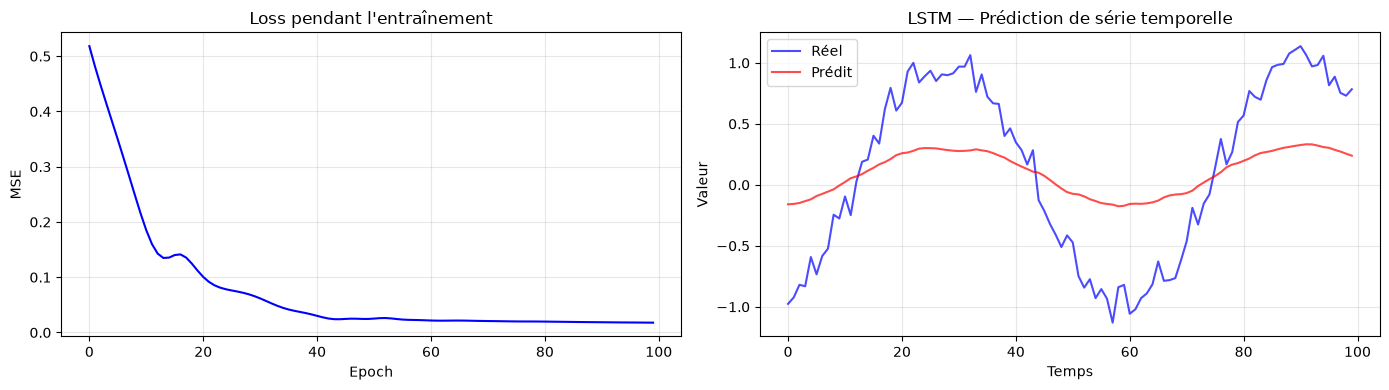

MSE Test : 0.316234


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# LSTM — Long Short-Term Memory
# Pour les données séquentielles : séries temporelles, texte, audio

# Créer une série temporelle : sin(x) + bruit
np.random.seed(42)
t = np.linspace(0, 100, 1000)
serie = np.sin(t) + 0.1 * np.random.randn(1000)

# Préparer les données pour LSTM
def create_sequences(data, seq_len=20):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

seq_len = 20
X_seq, y_seq = create_sequences(serie, seq_len)

# Split
split = int(0.8 * len(X_seq))
X_train = torch.FloatTensor(X_seq[:split]).unsqueeze(-1)  # (N, seq, 1)
y_train = torch.FloatTensor(y_seq[:split])
X_test  = torch.FloatTensor(X_seq[split:]).unsqueeze(-1)
y_test  = torch.FloatTensor(y_seq[split:])

print(f"X_train shape : {X_train.shape}")  # (N, seq_len, features)
print(f"y_train shape : {y_train.shape}")

# Architecture LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # dernière sortie
        return out.squeeze()

model = LSTMModel().to(device)
print(f"\nParamètres LSTM : {sum(p.numel() for p in model.parameters()):,}")

# Entraînement
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

losses = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(X_train.to(device))
    loss = criterion(output, y_train.to(device))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Prédictions
model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device)).cpu().numpy()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(losses, color="blue")
axes[0].set_title("Loss pendant l'entraînement")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE")
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_test.numpy()[:100], label="Réel", color="blue", alpha=0.7)
axes[1].plot(y_pred[:100], label="Prédit", color="red", alpha=0.7)
axes[1].set_title("LSTM — Prédiction de série temporelle")
axes[1].set_xlabel("Temps"); axes[1].set_ylabel("Valeur")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

mse = np.mean((y_pred - y_test.numpy())**2)
print(f"MSE Test : {mse:.6f}")

Image originale shape : torch.Size([1, 28, 28])
Label : 5


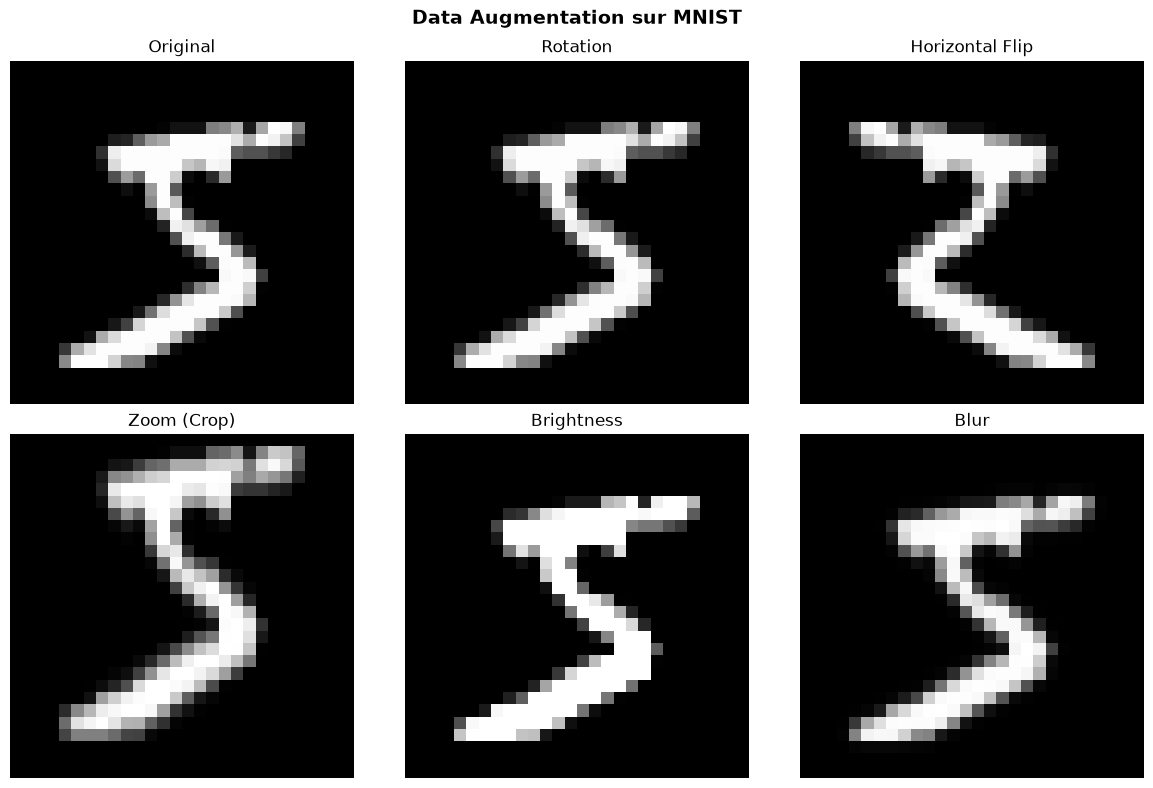


=== PIPELINE D'AUGMENTATION ===
Train : Rotation + Translation + Crop + Normalize
Test  : Normalize seulement (pas d'augmentation sur le test !)

Règle importante : on augmente UNIQUEMENT le train, jamais le test !


In [1]:
import torch
import torchvision.transforms as transforms
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# DATA AUGMENTATION
# Technique pour augmenter artificiellement la taille du dataset
# En appliquant des transformations aléatoires aux images
# → Le modèle voit plus de variété → moins d'overfitting

# Charger une image MNIST pour démonstration
dataset = torchvision.datasets.MNIST(root="./data", train=True, download=False,
                                      transform=transforms.ToTensor())
image, label = dataset[0]

print(f"Image originale shape : {image.shape}")
print(f"Label : {label}")

# Différentes augmentations
augmentations = {
    "Original": transforms.ToTensor(),
    "Rotation": transforms.Compose([
        transforms.RandomRotation(30),
        transforms.ToTensor()
    ]),
    "Horizontal Flip": transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor()
    ]),
    "Zoom (Crop)": transforms.Compose([
        transforms.RandomResizedCrop(28, scale=(0.7, 1.0)),
        transforms.ToTensor()
    ]),
    "Brightness": transforms.Compose([
        transforms.ColorJitter(brightness=0.8),
        transforms.ToTensor()
    ]),
    "Blur": transforms.Compose([
        transforms.GaussianBlur(kernel_size=3),
        transforms.ToTensor()
    ]),
}

# Dataset original sans transform
dataset_raw = torchvision.datasets.MNIST(
    root="./data", train=True, download=False, transform=None
)
image_pil, _ = dataset_raw[0]

# Visualiser
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (nom, transform) in zip(axes.flat, augmentations.items()):
    img_augmented = transform(image_pil)
    ax.imshow(img_augmented.squeeze(), cmap="gray")
    ax.set_title(nom, fontsize=12)
    ax.axis("off")

plt.suptitle("Data Augmentation sur MNIST", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Pipeline d'augmentation complet pour l'entraînement
train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(28, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("\n=== PIPELINE D'AUGMENTATION ===")
print("Train : Rotation + Translation + Crop + Normalize")
print("Test  : Normalize seulement (pas d'augmentation sur le test !)")
print("\nRègle importante : on augmente UNIQUEMENT le train, jamais le test !")